In [1]:
%pip install tensorflow

  Using cached absl_py-2.1.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-macosx_10_9_x86_64.whl.metadata (5.2 kB)
  Using cached ml_dtypes-0.3.2-cp311-cp311-macosx_10_9_universal2.whl.metadata (20 kB)
  Using cached tensorboard-2.16.2-py3-none-any.whl.metadata (1.6 kB)
  Using cached namex-0.0.8-py3-none-any.whl.metadata (246 bytes)
  Using cached tensorboard_data_server-0.7.2-py3-none-macosx_10_9_x86_64.whl.metadata (1.1 kB)
  Using cached markdown_it_py-3.0.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.6/259.6 MB 10.1 MB/s eta 0:00:0000:0100:01
Using cached absl_py-2.1.0-py3-none-any.whl (133 kB)
Using cached astunparse-1.6.3-py2.py3-none-any.whl (12 kB)
Using cached google_pasta-0.2.0-py3-none-any.whl (57 kB)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

2025-02-21 19:41:49.810964: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
df = pd.read_csv('/Users/elyas/vscode/market_analysis_03_office/data/preprocessed_not_standardized.csv')

In [4]:
df = df[['period','appreciation_return', 'available_df_direct', 'demand_sf', 'net_delivered_sf', 'bond_yield_10yr_x', 'three_yr_inf_exp', 'fed_funds_rate', 'cmbs_to_gdp', 'market_cap_rate']]


In [5]:
#conver period into datetime and index
df['period'] = pd.to_datetime(df['period'])
df = df.set_index('period')

In [6]:
#drop available_df_direct
df = df.drop(columns=['available_df_direct'])

#forward fill the missing vlaue for cmbs_to_gdp
df['cmbs_to_gdp'] = df['cmbs_to_gdp'].fillna(method='ffill')

/var/folders/5t/k32b1zys181cv4n2nz_7rq1c0000gp/T/ipykernel_15221/3630024540.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['cmbs_to_gdp'] = df['cmbs_to_gdp'].fillna(method='ffill')


Epoch 1/100


/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - loss: 0.1723 - val_loss: 0.0533
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1300 - val_loss: 0.0328
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1026 - val_loss: 0.0291
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0971 - val_loss: 0.0320
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0967 - val_loss: 0.0299
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0900 - val_loss: 0.0250
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0719 - val_loss: 0.0227
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0724 - val_loss: 0.0229
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0591 - val_loss: 0.0231
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0659 - val_loss: 0.0223
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0605 - val_loss: 0.0234
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0592 - val_loss: 0.0268


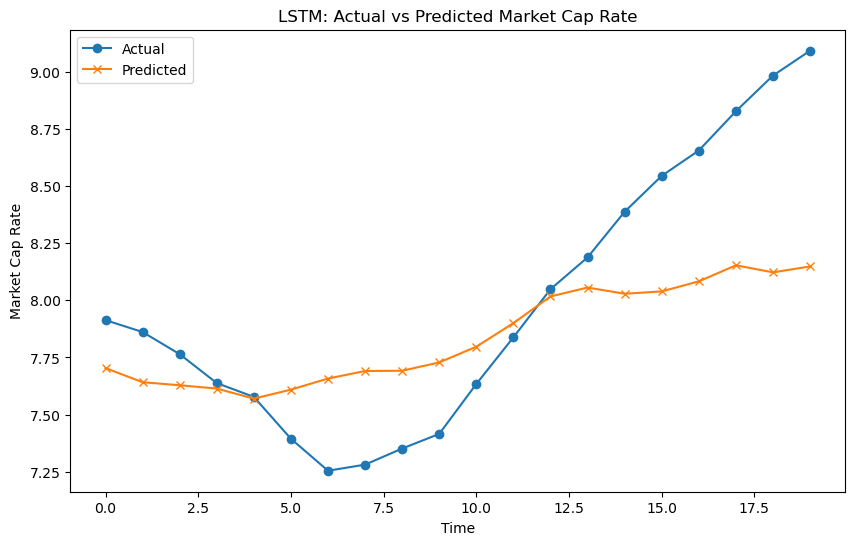

<Sequential name=sequential_1, built=True>

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

def prepare_data(df, target_col='market_cap_rate', lag=3):
    """Prepare the dataset for LSTM with lag features and normalization."""
    # Drop missing target values
    df = df.dropna(subset=[target_col])
    
    # Define input columns (excluding target)
    input_cols = df.columns.drop(target_col)
    
    # Normalize the entire dataframe using Min-Max scaling
    scaler = MinMaxScaler()
    df_scaled_full = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    
    # Create lag features only for input columns
    df_features = df_scaled_full[input_cols].copy()
    for i in range(1, lag + 1):
        for col in input_cols:
            df_features[f'{col}_lag_{i}'] = df_features[col].shift(i)
            
    # Drop rows with NaN values due to lag creation
    df_features = df_features.dropna().reset_index(drop=True)
    
    # Adjust target to align with the lagged features (drop first 'lag' rows)
    y = df_scaled_full[target_col].iloc[lag:].reset_index(drop=True)
    
    # Reshape features into 3D format: (samples, time steps, features)
    # Here, each sample consists of (lag+1) time steps and len(input_cols) features per time step.
    X_reshaped = df_features.values.reshape((df_features.shape[0], lag + 1, len(input_cols)))
    
    return X_reshaped, y.values, scaler

def build_lstm(input_shape):
    """Build and compile a simple LSTM model."""
    model = Sequential()
    model.add(LSTM(units=50, activation='relu', input_shape=input_shape))
    model.add(Dropout(0.2))  # Dropout to prevent overfitting
    model.add(Dense(1))  # Output layer (predicting one value: market cap rate)
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

def run_lstm(df, target_col='market_cap_rate', lag=3, epochs=100, batch_size=16):
    """Prepare data, train LSTM, and evaluate performance."""
    # Prepare data
    X, y, scaler = prepare_data(df, target_col, lag)
    
    # Train-test split (80-20)
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    # Build LSTM model
    model = build_lstm(input_shape=(X_train.shape[1], X_train.shape[2]))
    
    # Train the model with early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(
        X_train, y_train, 
        validation_data=(X_test, y_test),
        epochs=epochs, batch_size=batch_size, 
        callbacks=[early_stopping], verbose=1
    )
    
    # Predict on test data
    y_pred = model.predict(X_test)
    
    # Inverse scale predictions and actual values
    num_features = scaler.n_features_in_  # should be 8 based on the original dataframe
    y_pred_original = scaler.inverse_transform(np.c_[np.zeros((len(y_pred), num_features - 1)), y_pred])[:, -1]
    y_test_original = scaler.inverse_transform(np.c_[np.zeros((len(y_test), num_features - 1)), y_test])[:, -1]
    
    # Evaluate performance
    mae = mean_absolute_error(y_test_original, y_pred_original)
    r2 = r2_score(y_test_original, y_pred_original)
    print(f"\n--- MODEL EVALUATION ---")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R² Score: {r2:.4f}")
    
    # Plot actual vs predicted
    plt.figure(figsize=(10, 6))
    plt.plot(y_test_original, label='Actual', marker='o')
    plt.plot(y_pred_original, label='Predicted', marker='x')
    plt.title('LSTM: Actual vs Predicted Market Cap Rate')
    plt.xlabel('Time')
    plt.ylabel('Market Cap Rate')
    plt.legend()
    plt.show()

    return model

# Example Usage
run_lstm(df, target_col='market_cap_rate', lag=3, epochs=100, batch_size=16)
